In [ ]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import datetime
import math
import random
import matplotlib.pyplot as plt
import PIL

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR, OneCycleLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from tqdm import tqdm
import logging
import time

from sklearn.metrics import confusion_matrix, classification_report, recall_score
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
!gdown 1DB-r714_Wr2J4boXFuvOHn6hUwUO3fgR

Downloading...
From (original): https://drive.google.com/uc?id=1DB-r714_Wr2J4boXFuvOHn6hUwUO3fgR
From (redirected): https://drive.google.com/uc?id=1DB-r714_Wr2J4boXFuvOHn6hUwUO3fgR&confirm=t&uuid=be8f2462-8fea-4a98-9c9b-56edd7165fca
To: /content/Agricultural pests detection.zip
100% 107M/107M [00:01<00:00, 68.0MB/s]


In [ ]:
import zipfile
import matplotlib.image as mpimg

# Unzip the file
zip_file_path = '/content/Agricultural pests detection.zip'
extract_dir = '/content/pests'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Data Preparation

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Create DataFrame for image paths and labels from dataset folder
def create_dataset_dataframe(dataset_path):
    image_paths = []
    labels = []

    # Get all class folders
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for class_name in classes:
        class_folder = os.path.join(dataset_path, class_name)

        # Get all image files in the class folder
        for filename in os.listdir(class_folder):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                image_path = os.path.join(class_folder, filename)
                image_paths.append(image_path)
                labels.append(class_name)

    # Create DataFrame
    df = pd.DataFrame({
        'image': image_paths,
        'label': labels
    })

    return df

# Create the dataset DataFrame
dataset_path = '/content/pests'
df = create_dataset_dataframe(dataset_path)
df = df.replace(to_replace= r'\\', value= '/', regex=True)


print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print(f"Classes: {sorted(df['label'].unique())}")
print("\nClass distribution:")
print(df['label'].value_counts())

# Split the data using sklearn train_test_split
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # Ensure balanced split across classes
)

print(f"\nTrain set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")
print(f"\nTrain data sample:")
train_data.head()

Total images: 5494
Number of classes: 12
Classes: ['ants', 'bees', 'beetle', 'catterpillar', 'earthworms', 'earwig', 'grasshopper', 'moth', 'slug', 'snail', 'wasp', 'weevil']

Class distribution:
label
bees            500
snail           500
ants            499
wasp            498
moth            497
grasshopper     485
weevil          485
earwig          466
catterpillar    434
beetle          416
slug            391
earthworms      323
Name: count, dtype: int64

Train set size: 4395
Test set size: 1099

Train data sample:


,image,label
1564,/content/pests/earthworms/earthworms (134).jpg,earthworms
3172,/content/pests/moth/moth (136).jpg,moth
5205,/content/pests/wasp/wasp (831).jpg,wasp
1736,/content/pests/earthworms/earthworms (11).jpg,earthworms
1014,/content/pests/ants/ants (324).jpg,ants


In [ ]:
from PIL import Image

class CustomDataset(Dataset):
    def __init__(self, input_df, transform=None):
        self.input_df = input_df
        self.transform = transform
        self.class_to_idx = {label: idx for idx, label in enumerate(sorted(input_df['label'].unique()))}
        self.labels = input_df['label'].map(self.class_to_idx).values
        self.image_paths = input_df['image'].values

    def __len__(self):
        return len(self.input_df['label'])

    def idx_to_label(self, idx):
        return list(self.class_to_idx.keys())[list(self.class_to_idx.values()).index(idx)]

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load the image
        image = Image.open(image_path).convert('RGB')

        # Apply transformations if any
        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = CustomDataset(train_data, transform=test_transform)
test_dataset = CustomDataset(test_data, transform=test_transform)

# Build Dataloader
batch_size = 16

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)


torch.Size([3, 224, 224])


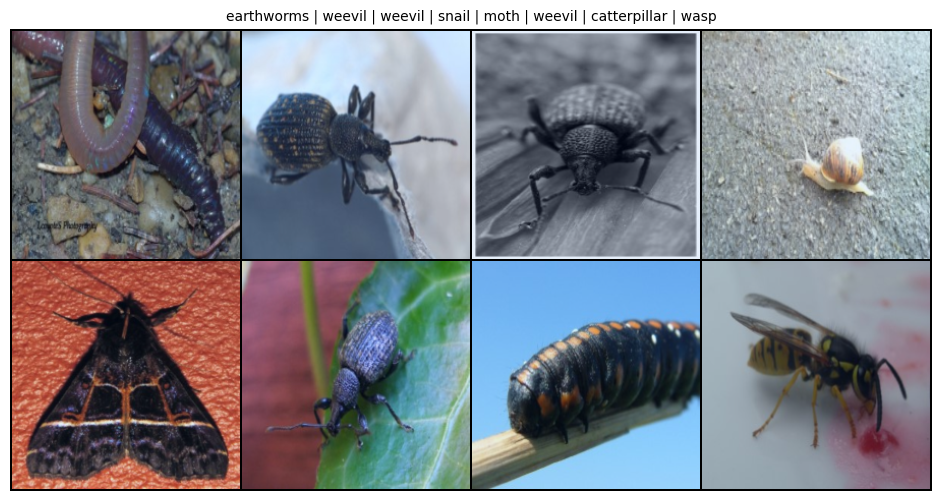

In [ ]:
from torchvision.utils import make_grid

# Get batch
train_features, train_labels = next(iter(train_dataloader))

# Sample input dimensions so we know what is going in to the model
sample_input = train_features[0]
print(sample_input.shape)

# Create grid
grid = make_grid(train_features[:8], nrow=4, normalize=True)

label_names = [train_dataset.idx_to_label(label.item()) for label in train_labels[:8]]
title = " | ".join(label_names)

plt.figure(figsize=(12, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.title(title, fontsize=10)
plt.axis('off')
plt.show()

# Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Depthwise Separable Convolution Module
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size=kernel_size,
                                   stride=stride, padding=padding, groups=in_ch, bias=False)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.act(x)

class InvertedResidual(nn.Module):
    """Inverted Residual Block with skip connection"""
    def __init__(self, in_channels, out_channels, stride=1, expand_ratio=6):
        super(InvertedResidual, self).__init__()

        self.stride = stride
        self.use_residual = stride == 1 and in_channels == out_channels

        hidden_dim = in_channels * expand_ratio

        layers = []

        # Expand
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True)
            ])

        # Depthwise + Pointwise
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride=stride,
                     padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.conv(x)
        else:
            return self.conv(x)

# CustomModel with SepConv, Dropout, and Stochastic Depth
class CustomModel(nn.Module):
    def __init__(self, num_classes=12):
        super(CustomModel, self).__init__()

        # Initial convolution - FIX: kernel_size was misspelled as kernal_size
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True)
        )

        # MobileNet blocks
        self.features = nn.Sequential(
            InvertedResidual(32, 16, 1, 1),
            InvertedResidual(16, 24, 2, 6),
            InvertedResidual(24, 24, 1, 6),
            InvertedResidual(24, 32, 2, 6),
            InvertedResidual(32, 32, 1, 6),
            InvertedResidual(32, 32, 1, 6),
            InvertedResidual(32, 64, 2, 6),
            InvertedResidual(64, 64, 1, 6),
            InvertedResidual(64, 64, 1, 6),
            InvertedResidual(64, 64, 1, 6),
            InvertedResidual(64, 96, 1, 6),
            InvertedResidual(96, 96, 1, 6),
            InvertedResidual(96, 96, 1, 6),
            InvertedResidual(96, 160, 2, 6),
            InvertedResidual(160, 160, 1, 6),
            InvertedResidual(160, 160, 1, 6),
            InvertedResidual(160, 320, 1, 6),
        )

        self.conv_last = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            nn.ReLU6(inplace=True)
        )

        # FIX: Missing commas in classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),  # Increased dropout
            nn.Linear(1280, 512),  # Added missing comma
            nn.ReLU6(inplace=True),  # Added missing comma
            nn.Dropout(0.2),  # Additional dropout layer
            nn.Linear(512, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.features(x)
        x = self.conv_last(x)
        x = self.classifier(x)
        return x

In [ ]:
# Create and initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomModel(num_classes=12).to(device)

In [ ]:
# Test with sample input
sample_input = train_features.to(device) # Batch size 16
with torch.no_grad():
    output = model(sample_input)
    print(f"Output shape: {output.shape}")

Output shape: torch.Size([16, 12])


# Hyperparams

In [ ]:
class LabelSmoothingCrossEntropy(nn.Module):
    """Label smoothing for better generalization"""
    def __init__(self, smoothing=0.15):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing

    def forward(self, x, target):
        confidence = 1. - self.smoothing
        logprobs = F.log_softmax(x, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

# Hyperparameters
# Optimized hyperparameters
learning_rate = 0.001
num_epochs = 100
weight_decay = 0.05

# Enhanced optimizer
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.08,
        betas=(0.9, 0.999)
    )

# Better scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )

# Keep your label smoothing (good choice!)
criterion = LabelSmoothingCrossEntropy(smoothing=0.15)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50, learning_rate=0.001):
    """Advanced training function with multiple optimizations"""

    # Loss function - using label smoothing for better generalization
    criterion = criterion
    # Optimizer - AdamW with weight decay
    optimizer = optimizer
    # Learning rate scheduler - Cosine annealing with warm restarts
    scheduler = scheduler

    # Early stopping
    best_val_acc = 0.0
    patience = 20
    patience_counter = 0

    # Training history
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    print("Starting training...")

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')

        for batch_idx, (data, target) in enumerate(train_pbar):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.7)

            optimizer.step()
            # Update learning rate
            scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

            # Update progress bar
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })

        # Calculate training metrics
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100. * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')

            for data, target in val_pbar:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                total_val += target.size(0)
                correct_val += (predicted == target).sum().item()

                val_pbar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Acc': f'{100.*correct_val/total_val:.2f}%'
                })

        # Calculate validation metrics
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100. * correct_val / total_val

        # Store metrics
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # Print epoch results
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
        print(f'  Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')
        print(f'  Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')

        # Early stopping and model saving
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            patience_counter = 0
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc': best_val_acc,
                'train_losses': train_losses,
                'train_accuracies': train_accuracies,
                'val_losses': val_losses,
                'val_accuracies': val_accuracies
            }, 'best_light_mobilenet_model.pth')
            print(f'  New best model saved! Val Acc: {best_val_acc:.2f}%')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs')
            break

        print('-' * 60)

    return {
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc
    }

# Enhanced data augmentation for better generalization
enhanced_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # More aggressive cropping
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),  # Useful for pest detection
    transforms.RandomRotation(25),  # Increased rotation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 2.0))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1))  # Increased erasing
])

# Create enhanced datasets
train_dataset_enhanced = CustomDataset(train_data, transform=enhanced_train_transform)
val_dataset = CustomDataset(test_data, transform=test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset_enhanced, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Train the model
training_history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, learning_rate=learning_rate)

Starting training...


Epoch 1/100 [Val]: 100%|██████████| 35/35 [00:04<00:00,  8.65it/s, Loss=2.4827, Acc=13.83%]


Epoch 1/100:
  Train Loss: 2.4806, Train Acc: 10.78%
  Val Loss: 2.4377, Val Acc: 13.83%
  Learning Rate: 0.000003
  New best model saved! Val Acc: 13.83%
------------------------------------------------------------


Epoch 2/100 [Val]: 100%|██████████| 35/35 [00:02<00:00, 11.87it/s, Loss=2.5654, Acc=18.56%]


Epoch 2/100:
  Train Loss: 2.4253, Train Acc: 14.77%
  Val Loss: 2.3638, Val Acc: 18.56%
  Learning Rate: 0.000055
  New best model saved! Val Acc: 18.56%
------------------------------------------------------------


...

Epoch 92/100 [Val]: 100%|██████████| 35/35 [00:03<00:00, 11.40it/s, Loss=1.5133, Acc=60.96%]


Epoch 92/100:
  Train Loss: 1.6175, Train Acc: 58.23%
  Val Loss: 1.5514, Val Acc: 60.96%
  Learning Rate: 0.000863
------------------------------------------------------------


Epoch 93/100 [Val]: 100%|██████████| 35/35 [00:03<00:00, 11.64it/s, Loss=1.5333, Acc=65.33%]


Epoch 93/100:
  Train Loss: 1.5985, Train Acc: 59.86%
  Val Loss: 1.4517, Val Acc: 65.33%
  Learning Rate: 0.000848
------------------------------------------------------------


Epoch 94/100 [Train]:  73%|███████▎  | 101/138 [00:31<00:11,  3.09it/s, Loss=1.6309, Acc=59.47%]

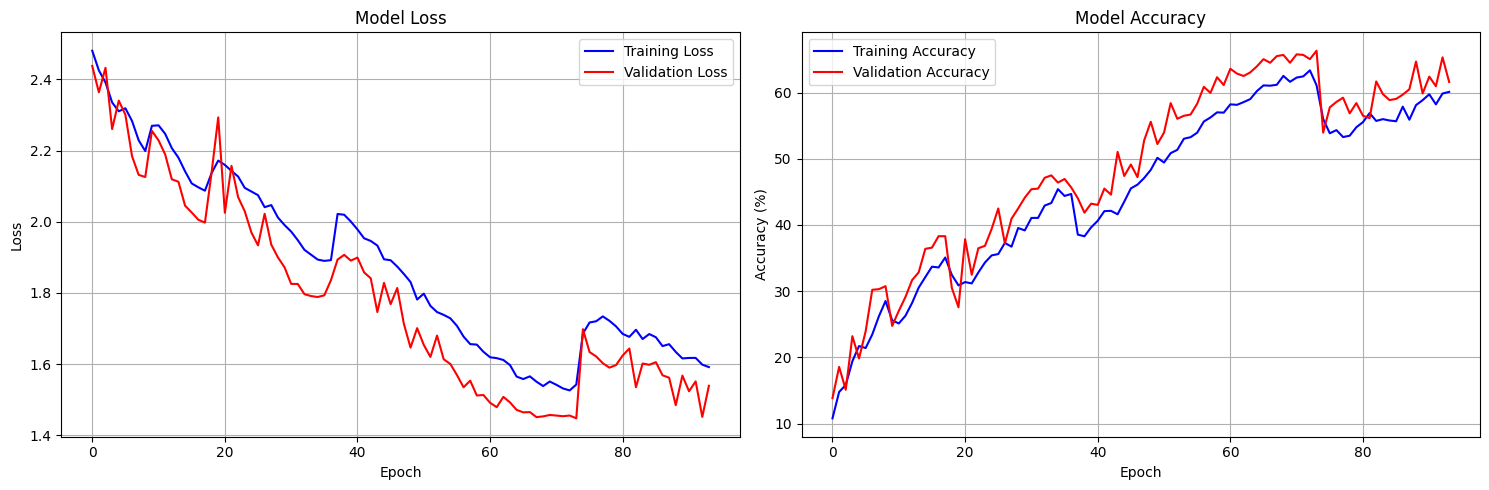

Evaluating: 100%|██████████| 35/35 [00:04<00:00,  8.15it/s]


Test Accuracy: 66.33%

Classification Report:
              precision    recall  f1-score   support

        ants       0.63      0.79      0.70       100
        bees       0.66      0.87      0.75       100
      beetle       0.39      0.08      0.14        83
catterpillar       0.53      0.32      0.40        87
  earthworms       0.57      0.46      0.51        65
      earwig       0.42      0.34      0.38        93
 grasshopper       0.56      0.68      0.62        97
        moth       0.79      0.93      0.86        99
        slug       0.45      0.38      0.41        78
       snail       0.86      0.92      0.89       100
        wasp       0.78      0.94      0.85       100
      weevil       0.81      0.95      0.88        97

    accuracy                           0.66      1099
   macro avg       0.62      0.64      0.61      1099
weighted avg       0.63      0.66      0.63      1099



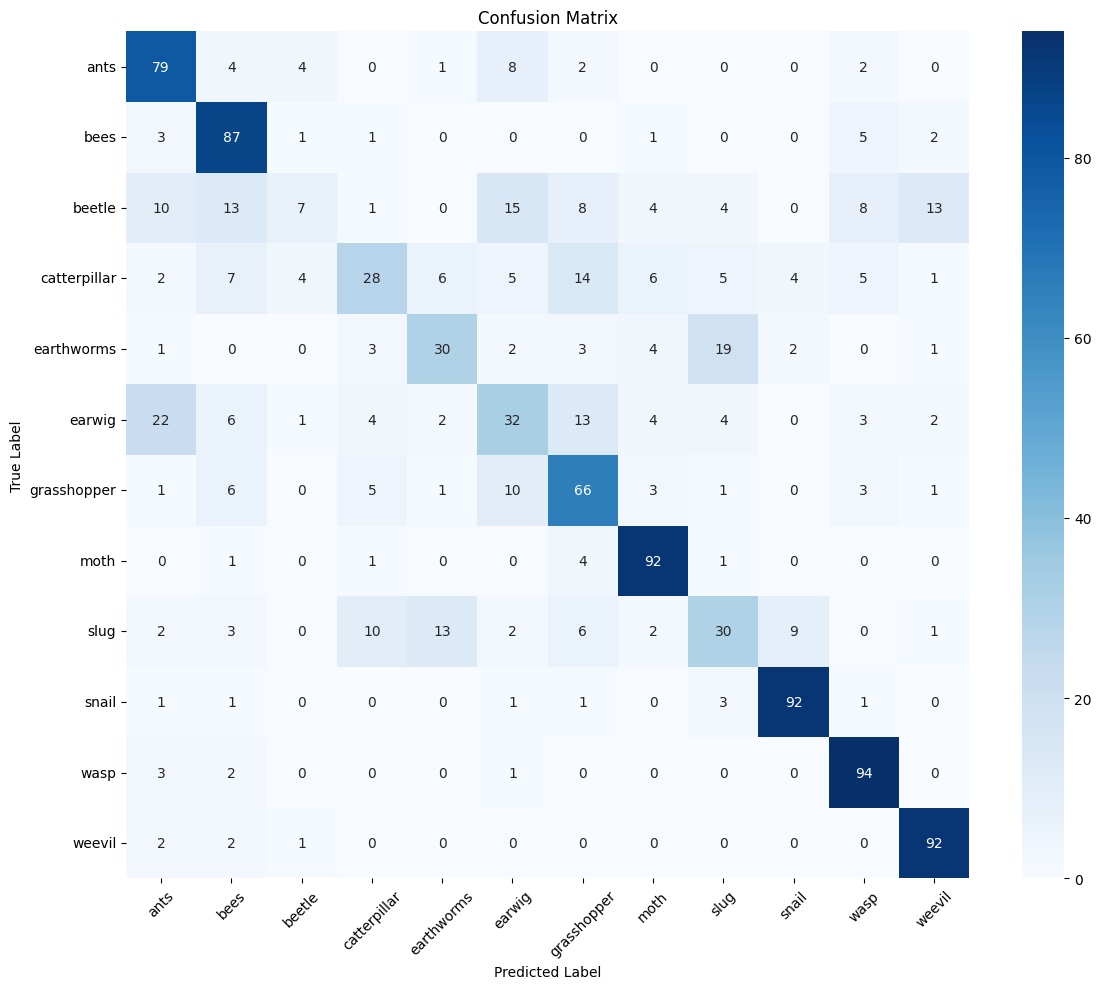

Layer (type:depth-idx)                   Output Shape              Param #
CustomModel                              [1, 12]                   --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 112, 112]         864
│    └─BatchNorm2d: 2-2                  [1, 32, 112, 112]         64
│    └─ReLU6: 2-3                        [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 320, 7, 7]            --
│    └─InvertedResidual: 2-4             [1, 16, 112, 112]         --
│    │    └─Sequential: 3-1              [1, 16, 112, 112]         896
│    └─InvertedResidual: 2-5             [1, 24, 56, 56]           --
│    │    └─Sequential: 3-2              [1, 24, 56, 56]           5,136
│    └─InvertedResidual: 2-6             [1, 24, 56, 56]           --
│    │    └─Sequential: 3-3              [1, 24, 56, 56]           8,832
│    └─InvertedResidual: 2-7             [1, 32, 28, 28]           --
│    │ 

In [ ]:
# Model Evaluation and Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot losses
    ax1.plot(history['train_losses'], label='Training Loss', color='blue')
    ax1.plot(history['val_losses'], label='Validation Loss', color='red')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot accuracies
    ax2.plot(history['train_accuracies'], label='Training Accuracy', color='blue')
    ax2.plot(history['val_accuracies'], label='Validation Accuracy', color='red')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_loader, class_names):
    """Comprehensive model evaluation"""
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, target in tqdm(test_loader, desc='Evaluating'):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    # Calculate accuracy
    accuracy = 100. * sum(np.array(all_predictions) == np.array(all_targets)) / len(all_targets)
    print(f'Test Accuracy: {accuracy:.2f}%')

    # Classification report
    print('\nClassification Report:')
    print(classification_report(all_targets, all_predictions, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_targets, all_predictions)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return accuracy, all_predictions, all_targets

# Load best model for evaluation
checkpoint = torch.load('best_light_mobilenet_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Get class names
class_names = sorted(train_data['label'].unique())

# Plot training history
plot_training_history(training_history)

# Evaluate model
test_accuracy, predictions, targets = evaluate_model(model, val_loader, class_names)


from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

In [ ]:
!pip install torchinfo

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to save the model in Google Drive
drive_save_path = '/content/drive/My Drive/best_light_mobilenet_model.pth' # You can change the path

# Load the best model checkpoint
checkpoint = torch.load('best_light_mobilenet_model.pth')

# Save the model state dictionary to Google Drive
torch.save(checkpoint['model_state_dict'], drive_save_path)

print(f"Model saved to: {drive_save_path}")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import files

# Define the filename
filename = "/content/best_light_mobilenet_model.pth"

# To download the file to your local machine, run the following code in a new cell:
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>